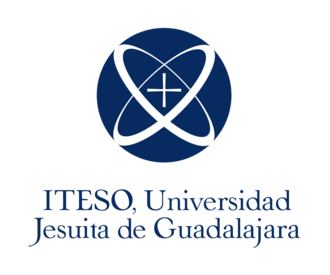

# Tarea 1. Reporte de prácticas 1 y 2 (Algoritmo Genéticos)

**Integrantes:**

- Valeria Esmer Lobo

- Dayanni Godoy Rosales

- Estephany Lisset Herrera Placencia

- Maria Fernanda Vargas Vaca

**Fecha:**
31 de agosto de 2026 

**Institución:**
Instituto Tecnológico y de Estudios Superiores de Occidente

**Materia:** Métodos de Inteligencia Artificial 


## Índice:






In [7]:
import numpy as np
import matplotlib.pyplot as plt



### Problema 1: Para números enteros


* **Funcion objetivo:** $$y=-(x-20.373)^2+100$$ esta sera una parabola invertida  ya que su término cuadraticos es negatuivo , donde alcanzara su maximo en 20.373

* **Objetivo del código:**  Buscar acercarse al numero **entero** mas cerca  de 20.373

* **Parametros a utilizar:** Bits por individuo(8), tamaño de poblacion (10), generaciones(20), Cruzamiento (1), mutación (probabilidad del 20%)

* **Representacion de los individuos:**  cada individuo se representa mediante  una cadena binaria de 8 bits en este caso 

* **Poblacion inicial:** (0,256) donde se genera aleatoriamente una población inicial de 10 individuos. Cada individuo corresponde a un número entero entre 0 y 255.

* **Evaluacion de la poblacion:** para cada individuo se calcula la funcion objetivo $y=-(x-20.373)^2+100$

* **Selección:** El programa ordena los individuos según valor  de (y) y conserva los mejores 50%.

* **Esquema representativo:** 10 individuos-> evaluación de (y) -> ordenar por desempeño -> seleccionar mejores 5 -> padres 

* **Cruzamiento:** Los padres seleccionado se convierten en representacion binaria , posteriormenete  se seleccionana al azar un punto  de cruzamiento  para producir nuevos hijos.

* **Mutación:** Con una probabilidad del 20%, se selecciona un hijo y uno de sus bits, el cual es invertido

* **Nueva generacion:** La nueva población se forma combinando los 5 mejores padres con los 5 hijos generados.

* **Conclusion personal:** El algoritmo genético permitió encontrar una solución cercana al máximo de la función objetivo mediante un proceso iterativo de selección, al finalizar las 20 generaciones, el algoritmo  como mejor solución encuentra cercano al máximo teórico de la función, cuyo punto máximo se encuentra en (x=20.373) y (y=100). Cada resolucion del algoritmos sera aleatorio donde  cambiara sus parametros en (X) y (y) cumpliuendo con las restricciones y/o funciones que se le plantean en el mismo 


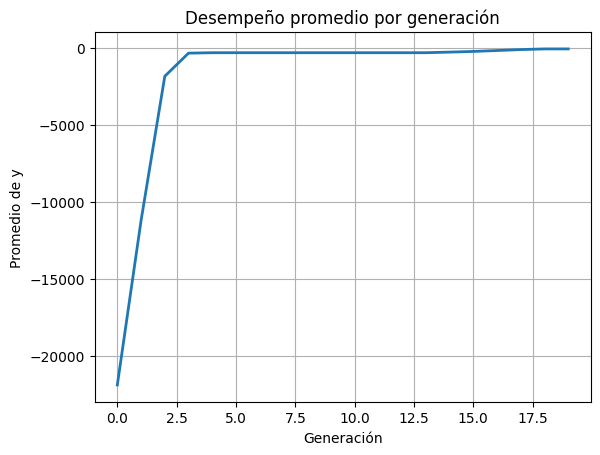

Resultado: x = 16, y = 80.8769


In [3]:
import numpy as np
import matplotlib.pyplot as plt
## numeros enteros 

# Inicialización de la población

nbits = 8
pobladores = 10 # debe ser divisible entre 4

# Población inicial: valores entre 0 y 255
xpadres = np.random.randint(0, 256, pobladores)

# Vector para guardar el promedio de cada generación
yprom = np.zeros(20)

# Número de generaciones
for n in range(20):
 
    # Evaluar la población
    # Función de ajuste:
    # y = -(x - 20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100

    # Guardar promedio de la generación
    yprom[n] = np.mean(y)

    # Ordenar y seleccionar mejores

    indices_ordenados = np.argsort(y)

    xpadres_ordenados = xpadres[indices_ordenados]

    # Nos quedamos con la mitad superior
    # (los individuos con mayor valor de y)
    mejores_padres = xpadres_ordenados[pobladores // 2:]
 
    # Convertir padres a binario

    padresbin = np.zeros(
        (pobladores // 2, nbits),
        dtype=int
    )

    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    
    # -------Cruzamiento----

    hijobin = np.zeros_like(padresbin)

    for k in range(pobladores // 4):

        # Punto de cruzamiento
        m = np.random.randint(1, nbits - 1)

        # Seleccionar dos padres
        padre1 = padresbin[2 * k]
        padre2 = padresbin[2 * k + 1]

        # Crear hijos
        hijobin[2 * k] = np.concatenate(
            (padre1[:m], padre2[m:])
        )

        hijobin[2 * k + 1] = np.concatenate(
            (padre2[:m], padre1[m:])
        )

    #----- mutacion----
    p = np.random.rand()

    if p >= 0.8:

        # Seleccionar aleatoriamente un hijo
        nhijo = np.random.randint(0, pobladores // 2)

        # Seleccionar aleatoriamente un bit
        nbit_mutacion = np.random.randint(0, nbits)

        # Invertir el bit
        hijobin[nhijo, nbit_mutacion] = (
            1 - hijobin[nhijo, nbit_mutacion]
        )

    # --------Decodificar hijos a decimal----
    
    hijodec = np.zeros(pobladores // 2, dtype=int)

    for i in range(pobladores // 2):

        val = 0

        for j in range(nbits):
            val += hijobin[i, j] * (2 ** j)

        hijodec[i] = val
    # -------Nueva población------

    xpadres = np.concatenate(
        (mejores_padres, hijodec)
    )

#------- Evaluar la población final------
y = -(xpadres - 20.373)**2 + 100


# --------Graficar promedio por generación-----

plt.plot(yprom, linewidth=2)

plt.title("Desempeño promedio por generación")
plt.xlabel("Generación")
plt.ylabel("Promedio de y")

plt.grid(True)
plt.show()

#-------Ubicar el máximo-----

val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")


In [8]:
def cruzamiento_dos_puntos(padre1, padre2, nbits):
    puntos = sorted(np.random.choice(range(1, nbits), 2, replace=False))
    m1, m2 = puntos[0], puntos[1]
    hijo1 = np.concatenate((padre1[:m1], padre2[m1:m2], padre1[m2:]))
    hijo2 = np.concatenate((padre2[:m1], padre1[m1:m2], padre2[m2:]))
    return hijo1, hijo2

def cruzamiento_uniforme(padre1, padre2, nbits):
    mascara = np.random.randint(0, 2, nbits)
    hijo1 = np.where(mascara == 1, padre1, padre2)
    hijo2 = np.where(mascara == 1, padre2, padre1)
    return hijo1, hijo2

### Código 1: Práctica 1 con Cruzamiento de Dos Puntos

**Definición del Problema:** Busca encontrar el valor máximo de la función $y = -(x - 20.373)^2 + 100$ dentro de un espacio de búsqueda de números enteros discretos (de 0 a 256).  

**Población y Selección:** Inicializa una población de 200 individuos enteros. En cada una de las 20 generaciones, evalúa la aptitud (fitness) de cada individuo, los ordena de menor a mayor y selecciona a la mejor mitad para reproducirse.

**Decodificación y Cruzamiento:** Convierte los padres seleccionados a cadenas binarias de 8 bits. Aplica el cruzamiento de dos puntos, el cual selecciona aleatoriamente dos índices de corte en la cadena de 8 bits e intercambia el segmento central entre los dos padres para generar dos hijos.
  
**Mutación y Reemplazo:** Aplica una mutación de un solo bit con un 20% de probabilidad. Finalmente, decodifica a los hijos de binario a entero y los integra con la mitad de los mejores padres para formar la población de la siguiente generación

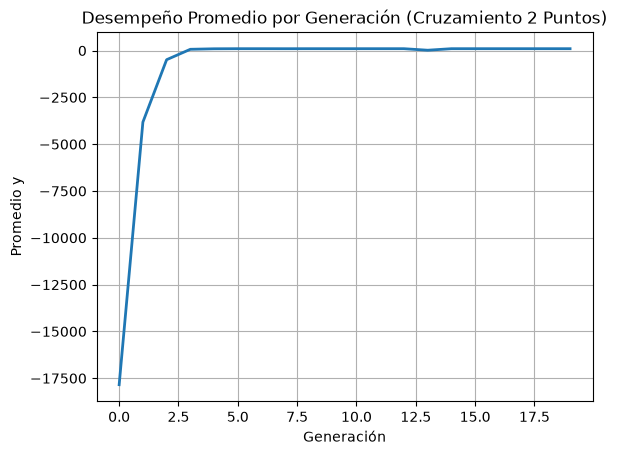

Resultado: x = 20, y = 99.8609


In [9]:
##-Codigo_1_Cruzamiento_2_Puntos-------
# --- Iniciar la Poblacion ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) 

# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento de dos puntos usando función ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k + 1] = hijo2

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

# --- Mostrar solución en pantalla ---
y = -(xpadres - 20.373)**2 + 100 

plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento 2 Puntos)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")

### Código 2: Práctica 1 con Cruzamiento Uniforme

**Definición del Problema:** Resuelve exactamente la misma función matemática y utiliza los mismos parámetros base (200 pobladores, enteros de 0 a 256, 20 generaciones).  

**Mecánica de Cruzamiento:** La diferencia principal radica en la reproducción. Aplica el cruzamiento uniforme, el cual no realiza cortes espaciales en la cadena. En su lugar, genera una máscara aleatoria de ceros y unos del mismo tamaño que el cromosoma (8 bits). Para cada posición, la máscara decide estadísticamente si el hijo hereda el gen del Padre 1 o del Padre 2, lo que promueve una mayor diversidad genética y rompe la dependencia de genes adyacentes.  

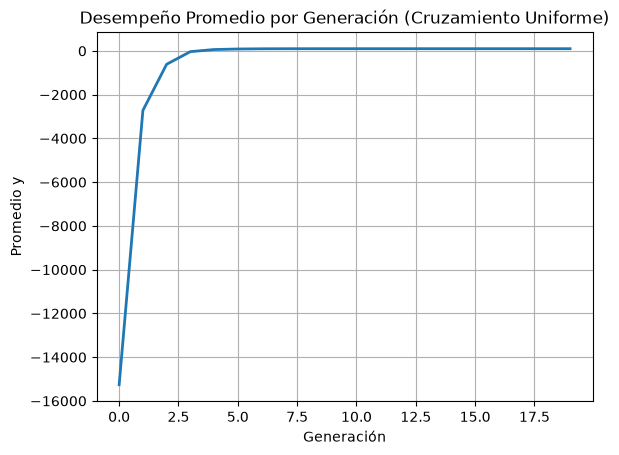

Resultado: x = 21, y = 99.6069


In [10]:
##-Codigo_1_Cruzamiento_Uniforme-------
# --- Iniciar la Población ---
# nbit ln(256)/ln(2)=8
nbits = 8
pobladores = 200 
xpadres = np.random.randint(0, 256, pobladores)
yprom = np.zeros(20) 

# Número de generaciones
for n in range(20):
    # ---- Evaluar y ordenar y = f(x) ----
    # Función de ajuste: y = -(x-20.373)^2 + 100
    y = -(xpadres - 20.373)**2 + 100
    yprom[n] = np.mean(y)

    # Crear los cromosomas (ordenando de menor a mayor según y)
    indicies_ordenas = np.argsort(y)
    xpadres_ordenados = xpadres[indicies_ordenas]

    # Nos quedamos con la mitad superior (los mejores evaluados)
    mejores_padres = xpadres_ordenados[pobladores // 2 :]

    # --- Decodificar a binario ---
    # Convertimos los números decimales a binario (8 columnas)
    padresbin = np.zeros((pobladores // 2, nbits), dtype=int)
    for i, val in enumerate(mejores_padres):
        for j in range(nbits):
            padresbin[i, j] = (int(val) >> j) & 1

    # --- Cruzamiento UNIFORME usando función ---
    hijobin = np.zeros_like(padresbin) 

    for k in range(pobladores // 4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k + 1]

        hijo1, hijo2 = cruzamiento_uniforme(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k + 1] = hijo2

    # --- Mutación ---
    p = np.random.rand()
    if p >= 0.8:
        # Seleccionar aleatoriamente una posición y un bit
        nhijo = np.random.randint(0, pobladores // 2)
        nbit = np.random.randint(0, nbits)

        # Invertir bit: si es 1 cambia a 0, y viceversa
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # --- Reemplazo --- 
    # Cambiar binario a decimal
    hijodec = np.zeros(pobladores // 2) 
    for i in range(pobladores // 2):
        val = 0
        for j in range(nbits):
            val += hijobin[i,j] * (2**j)
        hijodec[i] = val 

    # Anexar el nuevo hijo decimal a los xpadres
    xpadres = np.concatenate((mejores_padres, hijodec)).astype(int)

# --- Mostrar solución en pantalla ---
y = -(xpadres - 20.373)**2 + 100 

plt.plot(yprom, linewidth=2)
plt.title('Desempeño Promedio por Generación (Cruzamiento Uniforme)')
plt.xlabel('Generación')
plt.ylabel('Promedio y')
plt.grid(True)
plt.show()

# Ubicar el máximo 
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x = {xpadres[ind]}, y = {val:.4f}")

### Código 3: Práctica 2 con Cruzamiento de Dos Puntos

**Definición del Problema:** Evoluciona el problema para buscar el máximo de la función $y = -(x - 41.125)^2 + 200$ en un dominio continuo de números reales con límites de -100 a 100 y un tamaño de paso de 0.01.  

**Mapeo Real a Binario:** Calcula dinámicamente la longitud del cromosoma (15 bits) necesaria para representar los valores reales con la precisión requerida. Genera una población inicial de 512 individuos, transformando los valores enteros generados a sus equivalentes reales mediante una fórmula matemática.  

**Evaluación y Cruzamiento:** Ordena y selecciona a los 256 mejores individuos tras evaluarlos en la función. Aplica el cruzamiento de dos puntos sobre cadenas más largas (15 bits), intercambiando el material genético de la zona central de los padres para crear a los descendientes. 

**Mutación y Decodificación:** Ejecuta una mutación con probabilidad del 10%. Finalmente, transforma los hijos binarios a enteros y de enteros a números reales continuos para actualizar la matriz de la población durante 100 generaciones. 

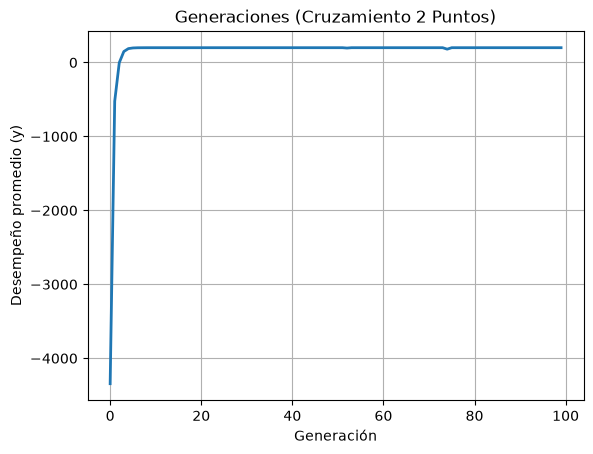

Resultado: x=40.6171, y=199.7420


In [11]:
##-Codigo_2_Cruzamiento_2_Puntos-------
#-------- inicializacion de la poblacion -------
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

x1 = np.random.randint(0, 2**nbits, num_poblacion)
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin
yprom = np.zeros(100)

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 
    yprom[i] = np.mean(y)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento de DOS PUNTOS usando función -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        hijo1, hijo2 = cruzamiento_dos_puntos(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k+1] = hijo2

    #-------- mutacion--------
    p = np.random.rand()
    if p > 0.90:
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- decodificacion y reemplazo ----
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento 2 Puntos)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")

### Código 4: Práctica 2 con Cruzamiento Uniforme

**Definición del Problema:** Mantiene la optimización de la función real $y = -(x - 41.125)^2 + 200$ con 512 pobladores y 100 generaciones, utilizando el mismo mapeo de variables reales a binarias (15 bits). 

**Mecánica de Cruzamiento:** Sustituye la recombinación clásica por el cruzamiento uniforme. Crea una máscara binaria de 15 posiciones que dictamina bit a bit qué información genética pasará del par de padres a cada hijo. En espacios de búsqueda más amplios como este (15 bits frente a 8), este método permite explorar combinaciones de valores reales de manera más dispersa y agresiva

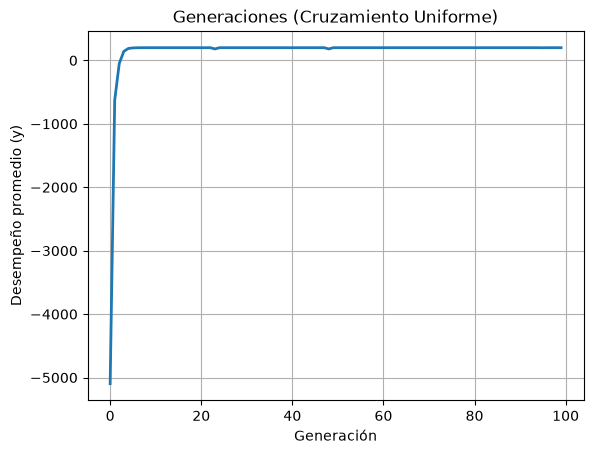

Resultado: x=41.0993, y=199.9993


In [12]:
##-Codigo_2_Cruzamiento_Uniforme-------
#-------- inicializacion de la poblacion -------
xmin = -100 # limite inferior
xmax = 100 # limite superior
tpaso = 0.01 # tamaño de paso

elementos = (xmax-xmin)/tpaso+1 # numero de elementos
nbits = int(np.ceil(np.log2(elementos))) # numero de bits
num_poblacion = 512 # tamaño de poblacion

x1 = np.random.randint(0, 2**nbits, num_poblacion)
x1real = (xmax-xmin)*x1 / (2**nbits-1) + xmin
yprom = np.zeros(100)

#------- iniciar numero de generaciones -------
for i in range(100):
    # evaluar los padres de la funcion objetivo
    y = -(x1real-41.125)**2 + 200 
    yprom[i] = np.mean(y)

    indices_ordenados = np.argsort(y)
    x1_ordenado = x1[indices_ordenados]
    x1real_ordenado = x1real[indices_ordenados]

    mejores_x1 = x1_ordenado[num_poblacion//2:]
    mejores_x1real = x1real_ordenado[num_poblacion//2:]

    padresbin = np.zeros((num_poblacion//2, nbits), dtype=int)
    for idx, val in enumerate(mejores_x1):
        for j in range(nbits):
            padresbin[idx, j] = (int(val) >> j) & 1

    #-------- cruzamiento UNIFORME usando función -----
    hijobin = np.zeros_like(padresbin)

    for k in range(num_poblacion//4):
        padre1 = padresbin[2*k]
        padre2 = padresbin[2*k+1]

        hijo1, hijo2 = cruzamiento_uniforme(padre1, padre2, nbits)
        hijobin[2*k] = hijo1
        hijobin[2*k+1] = hijo2

    #-------- mutacion--------
    p = np.random.rand()
    if p > 0.90:
        nhijo = np.random.randint(0, num_poblacion//2)
        nbit = np.random.randint(0, nbits)
        hijobin[nhijo, nbit] = 1 - hijobin[nhijo, nbit]

    # ---- decodificacion y reemplazo ----
    hijoent = np.zeros(num_poblacion//2)
    for idx in range(num_poblacion//2):
        val = 0
        for j in range(nbits):
            val += hijobin[idx, j] * (2**j)
        hijoent[idx] = val

    hijoreal = (xmax-xmin)*hijoent/(2**nbits-1) + xmin

    x1 = np.concatenate((mejores_x1, hijoent))
    x1real = np.concatenate((mejores_x1real, hijoreal))

#------- mostrar resultado en pantalla ------
plt.plot(yprom, linewidth=2)
plt.title("Generaciones (Cruzamiento Uniforme)")
plt.xlabel("Generación")
plt.ylabel("Desempeño promedio (y)")
plt.grid(True)
plt.show()

y = -(x1real-41.125)**2 + 200
val = np.max(y)
ind = np.argmax(y)

print(f"Resultado: x={x1real[ind]:.4f}, y={val:.4f}")

cambios de dayanni